# Lab Manual 3 — Data Analysis and Visualization
**Dataset:** Sample Superstore (sales, profit, discount, region, category)

This notebook goes through each lab task step by step. Every chart has a short, plain-English explanation next to it — no heavy jargon.

## 0. Setup and data cleaning

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make charts look clean and readable
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Load the raw data
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Quick look at the data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Check for missing values and fix data types
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")

# Convert Order Date to an actual date (it is currently just text)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

# Save a cleaned copy of the dataset (this is the CSV we submit)
df.to_csv('superstore_cleaned.csv', index=False)

df.info()

Missing values per column:
0 total missing cells
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str

## Task 1 — Same data, three chart types
We take **monthly sales for 2017** and draw it three ways: bar, line, and pie.
This shows what each chart type is actually good at.

In [4]:
# Summarize sales by month, for the year 2017
sales_2017 = df[df['Order Date'].dt.year == 2017]
monthly_sales = sales_2017.groupby(sales_2017['Order Date'].dt.month)['Sales'].sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales.index = month_names

monthly_sales

Jan     43971.3740
Feb     20301.1334
Mar     58872.3528
Apr     36521.5361
May     44261.1102
Jun     52981.7257
Jul     45264.4160
Aug     63120.8880
Sep     87866.6520
Oct     77776.9232
Nov    118447.8250
Dec     83829.3188
Name: Sales, dtype: float64

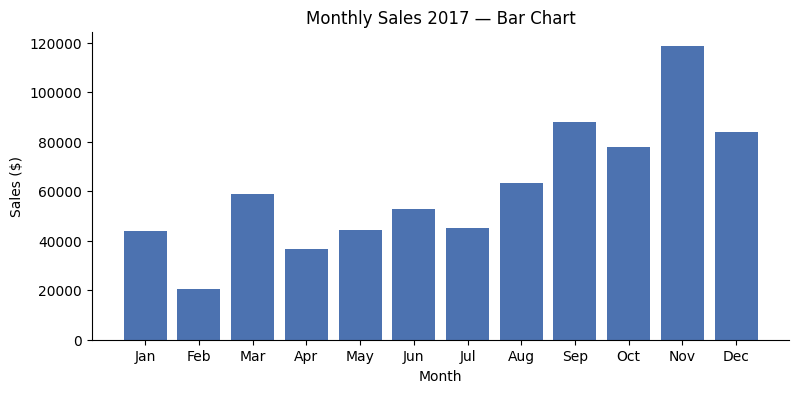

In [5]:
# Bar chart
plt.figure(figsize=(9, 4))
plt.bar(monthly_sales.index, monthly_sales.values, color='#4C72B0')
plt.title('Monthly Sales 2017 — Bar Chart')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.show()

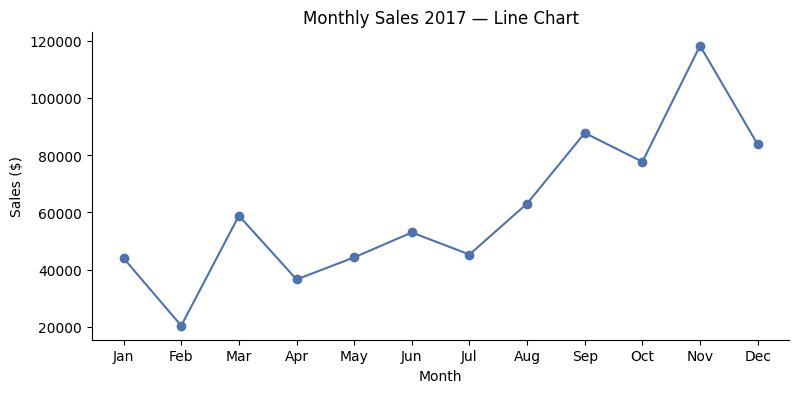

In [6]:
# Line chart
plt.figure(figsize=(9, 4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#4C72B0')
plt.title('Monthly Sales 2017 — Line Chart')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.show()

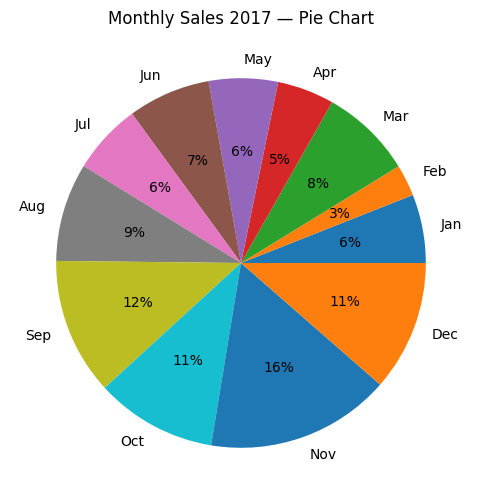

In [7]:
# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(monthly_sales.values, labels=monthly_sales.index, autopct='%1.0f%%')
plt.title('Monthly Sales 2017 — Pie Chart')
plt.show()

**Which chart shows the trend best, and which one hides it?**

The **line chart** shows the trend best. It has a clear left-to-right order (Jan → Dec), so we can immediately see sales dip early in the year and rise toward the end.

The **pie chart** hides the trend completely. A pie chart has no sense of time order — all 12 slices just sit around a circle, so we cannot tell which month came before another just by looking at it. It also becomes cluttered with 12 slices, since a pie chart works best with only a few categories.

The **bar chart** sits in between — it shows each month's value clearly, but the time-order pattern is a little less obvious than in the line chart.

## Task 2 — Picking the right chart for the right question
For each question below, we pick a chart type, build it, and explain why it fits.

### 2a. Compare total sales across the top 5 sub-categories → Bar chart

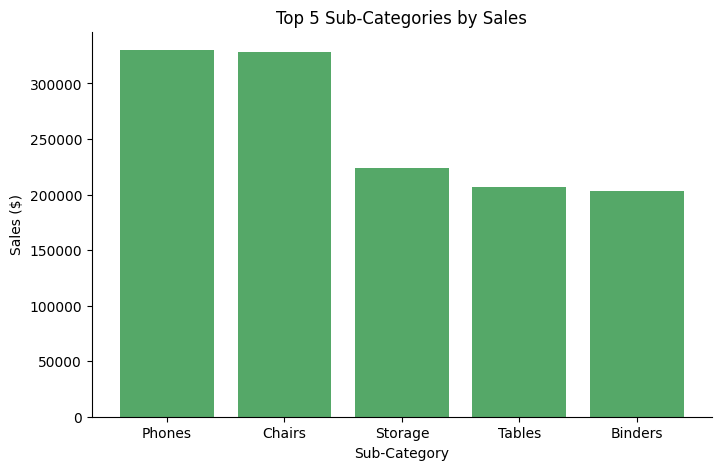

In [8]:
# Get the top 5 sub-categories by total sales
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
plt.bar(top5_subcat.index, top5_subcat.values, color='#55A868')
plt.title('Top 5 Sub-Categories by Sales')
plt.ylabel('Sales ($)')
plt.xlabel('Sub-Category')
plt.show()

**Why a bar chart:** We are comparing exact totals for 5 separate categories. A bar chart makes it easy to line up the tops of the bars and see who is highest and by how much.
**Why a pie chart would be weaker:** With 5 close-in-size slices, it is hard for the eye to judge small differences in angle, and pie charts do not show exact values clearly.

### 2b. Show the revenue trend over time → Line chart

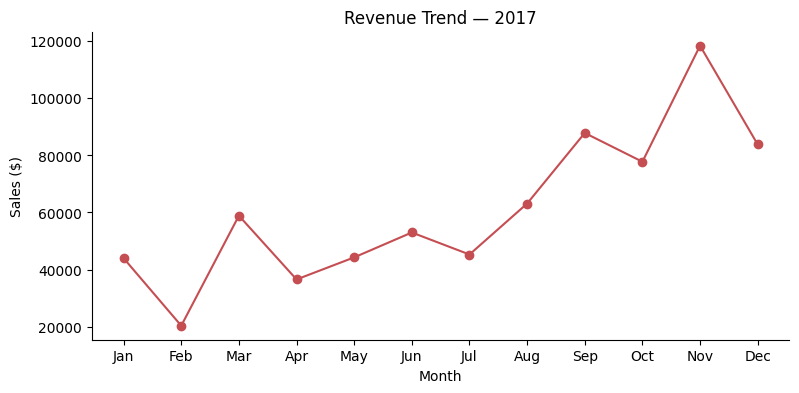

In [9]:
# Reuse the monthly sales data from Task 1
plt.figure(figsize=(9, 4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#C44E52')
plt.title('Revenue Trend — 2017')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.show()

**Why a line chart:** Time has a natural order, and a line connects each point so the eye can follow the trend (up, down, or flat) across months.
**Why a bar chart would be weaker here:** With many time points, bars start to look cluttered and it is harder to see the overall direction — the connecting line is what makes a trend visible.

### 2c. Show the distribution of order-line sales values → Histogram

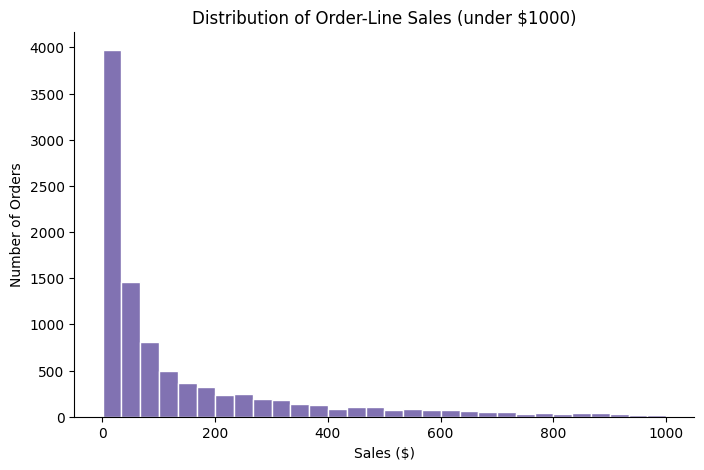

In [10]:
# Use the raw Sales column directly. Sales values have a few very large outliers,
# so we zoom into orders under $1000 to see the shape more clearly.
plt.figure(figsize=(8, 5))
plt.hist(df[df['Sales'] < 1000]['Sales'], bins=30, color='#8172B2', edgecolor='white')
plt.title('Distribution of Order-Line Sales (under $1000)')
plt.xlabel('Sales ($)')
plt.ylabel('Number of Orders')
plt.show()

**Why a histogram:** A histogram groups values into ranges (bins) and shows how many orders fall into each range, which is exactly what "distribution" means — where most values sit, and how spread out they are.
**Why "bar of averages" would be weaker:** A single average hides the shape entirely — it cannot show us that most orders are small with a long tail of a few large ones.

### 2d. Show the relationship between discount level and profit → Scatter plot

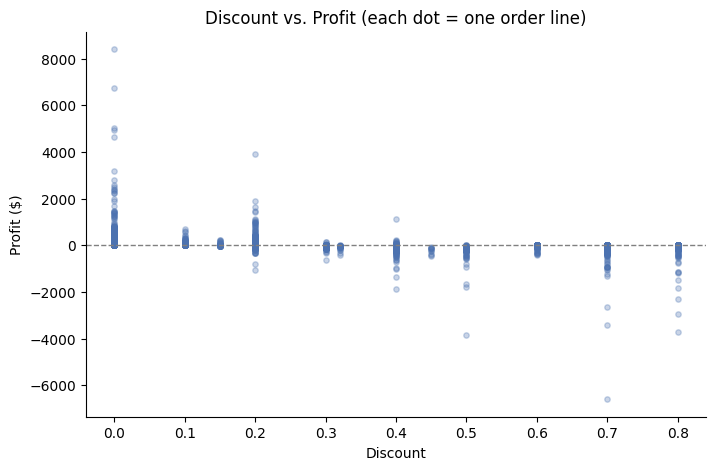

In [11]:
# Use the raw Discount and Profit columns directly
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#4C72B0', s=15)
plt.title('Discount vs. Profit (each dot = one order line)')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.show()

**Why a scatter plot:** We have two numeric variables and want to see if they move together. Each dot is one order, so we can spot the overall pattern (here, profit tends to fall as discount rises).
**Why a line chart would be weaker:** A line chart assumes points are in an order (like time). Discount values are not naturally ordered per order-line, so connecting them with a line would be misleading — a scatter plot is the honest choice for correlation.

## Task 3 — Choosing the right colors
Here we recolor three charts using the correct color type for each situation:
categorical, sequential, and diverging.

### 3a. Region sales — categorical palette (distinct, unordered groups)

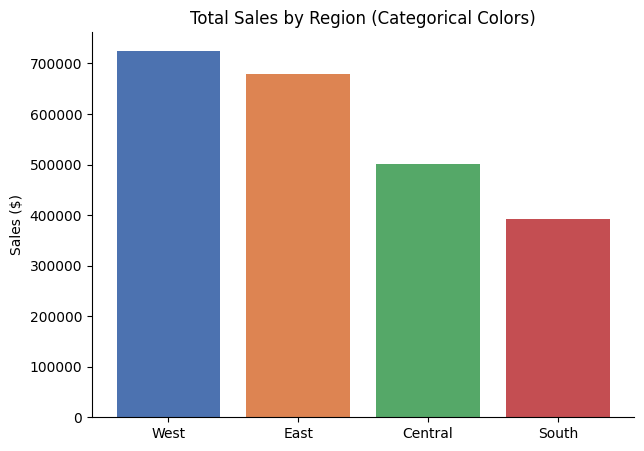

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# A fixed set of distinguishable colors — one per region, no natural order between them
categorical_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(7, 5))
plt.bar(region_sales.index, region_sales.values, color=categorical_colors)
plt.title('Total Sales by Region (Categorical Colors)')
plt.ylabel('Sales ($)')
plt.show()

**Why categorical colors:** Regions are separate groups with no order (East is not "more" than West). A fixed set of clearly different colors — not a gradient — makes each group easy to tell apart.

### 3b. Region × Category — heatmap with a sequential palette (low → high)

In [13]:
# Build a table of sales: rows = region, columns = category
region_cat = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
region_cat

Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


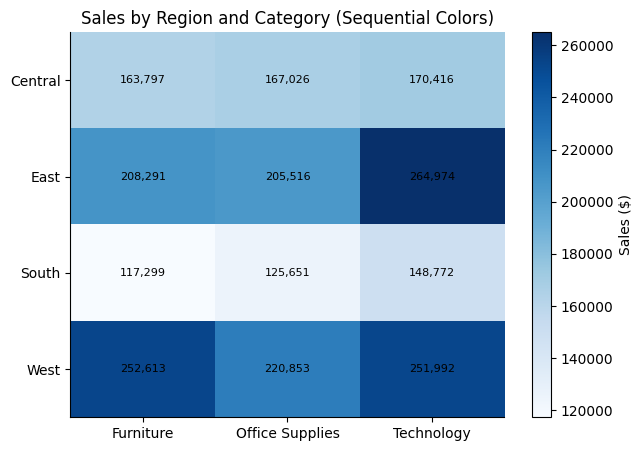

In [14]:
plt.figure(figsize=(7, 5))
# 'Blues' is a sequential palette: light = low sales, dark = high sales
plt.imshow(region_cat.values, cmap='Blues', aspect='auto')
plt.colorbar(label='Sales ($)')
plt.xticks(range(len(region_cat.columns)), region_cat.columns)
plt.yticks(range(len(region_cat.index)), region_cat.index)
plt.title('Sales by Region and Category (Sequential Colors)')

# Add the numbers on top of each cell so the exact values are readable
for i in range(len(region_cat.index)):
    for j in range(len(region_cat.columns)):
        plt.text(j, i, f"{region_cat.values[i, j]:,.0f}",
                 ha='center', va='center', fontsize=8)
plt.show()

**Why a sequential palette:** Sales is a magnitude that goes from low to high — one color, light to dark, naturally maps to "less" and "more" without implying separate categories.

### 3c. Monthly profit — diverging palette (crosses zero)

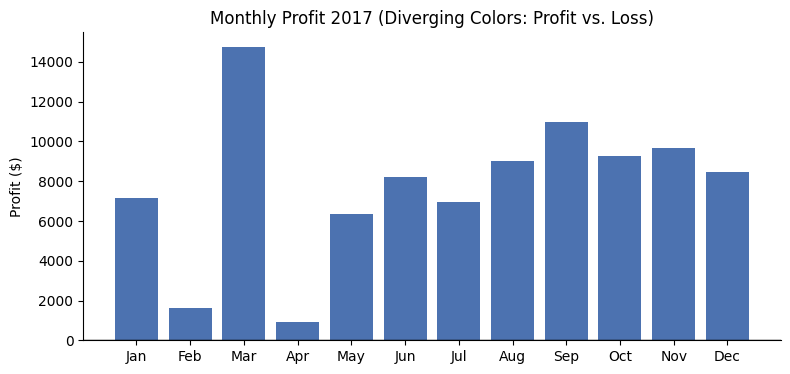

In [15]:
monthly_profit_2017 = sales_2017.groupby(sales_2017['Order Date'].dt.month)['Profit'].sum()
monthly_profit_2017.index = month_names

# Diverging colors: blue for profit (above zero), orange for loss (below zero)
colors = ['#4C72B0' if v >= 0 else '#DD8452' for v in monthly_profit_2017.values]

plt.figure(figsize=(9, 4))
plt.bar(monthly_profit_2017.index, monthly_profit_2017.values, color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Monthly Profit 2017 (Diverging Colors: Profit vs. Loss)')
plt.ylabel('Profit ($)')
plt.show()

**Why a diverging palette:** Profit has a meaningful midpoint — zero. Values above zero (profit) and below zero (loss) are opposite outcomes, so two different hues meeting at a neutral zero line make the "good months vs. bad months" split immediately clear.

## Task 4 — Accessibility: contrast and colorblindness
We check whether our color choices are actually readable for everyone.

### 4a. WCAG contrast ratio checker

In [16]:
def relative_luminance(rgb):
    """Calculate how 'bright' a color appears, following the WCAG formula.
    rgb should be a tuple like (255, 0, 0) for red."""
    def channel(c):
        c = c / 255
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = [channel(c) for c in rgb]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def contrast_ratio(rgb1, rgb2):
    """Calculate the WCAG contrast ratio between two RGB colors."""
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

In [17]:
# Test the function against the colors used in Task 3, all paired against a white background
white = (255, 255, 255)

colors_to_test = {
    'Region blue (#4C72B0)':   (76, 114, 176),
    'Region orange (#DD8452)': (221, 132, 82),
    'Region green (#55A868)':  (85, 168, 104),
    'Region red (#C44E52)':    (196, 78, 82),
    'Heatmap dark blue':       (8, 48, 107),
}

print(f"{'Color':30s} {'Contrast Ratio':>15s}  {'Passes AA (4.5:1)?'}")
for name, rgb in colors_to_test.items():
    ratio = contrast_ratio(rgb, white)
    passes = "Yes" if ratio >= 4.5 else "No - FAILS"
    print(f"{name:30s} {ratio:15.2f}  {passes}")

Color                           Contrast Ratio  Passes AA (4.5:1)?
Region blue (#4C72B0)                     4.84  Yes
Region orange (#DD8452)                   2.80  No - FAILS
Region green (#55A868)                    2.92  No - FAILS
Region red (#C44E52)                      4.61  Yes
Heatmap dark blue                        12.76  Yes


**Result:** Colors with a contrast ratio below 4.5:1 against white fail the WCAG AA text-contrast rule and would need to be darkened, or only used for large shapes (like bars) rather than for small text.

### 4b. Loss vs. gain chart — red/green problem and the fix

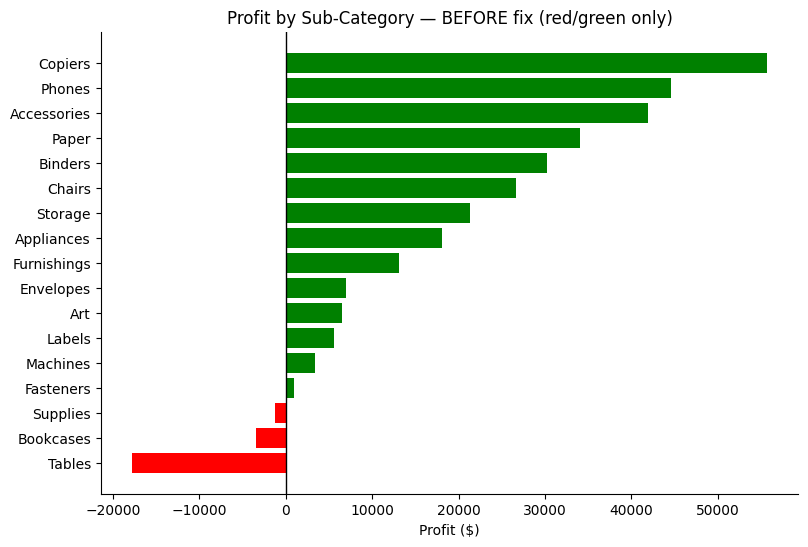

In [18]:
profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# --- Version 1: the PROBLEM version — meaning is carried by color alone ---
colors_bad = ['red' if v < 0 else 'green' for v in profit_by_subcat.values]

plt.figure(figsize=(9, 6))
plt.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_bad)
plt.axvline(0, color='black', linewidth=1)
plt.title('Profit by Sub-Category — BEFORE fix (red/green only)')
plt.xlabel('Profit ($)')
plt.show()

If we simulate red-green colorblindness, red and green bars can look almost the same shade, so a colorblind viewer cannot tell losses from gains just by color. Below is a simple simulation that mimics how a red-green colorblind person perceives these colors.

In [19]:
def simulate_red_green_colorblind(rgb):
    """A simplified simulation of red-green color blindness (deuteranopia).
    It reduces the red-green difference, which is the channel that
    people with this condition struggle to distinguish."""
    r, g, b = rgb
    # Average red and green together, since that's the distinction that is lost
    avg = (r + g) / 2
    return (avg, avg, b)


# Show 'red' and 'green' before and after the simulation
red_rgb = (255, 0, 0)
green_rgb = (0, 128, 0)

print("Normal vision:")
print(f"  Red:   {red_rgb}")
print(f"  Green: {green_rgb}")

print("\nSimulated red-green colorblind vision:")
print(f"  Red:   {simulate_red_green_colorblind(red_rgb)}")
print(f"  Green: {simulate_red_green_colorblind(green_rgb)}")
print("\nNotice the two simulated colors are much closer together — this is why")
print("red vs. green alone is a poor way to encode 'loss' vs. 'gain'.")

Normal vision:
  Red:   (255, 0, 0)
  Green: (0, 128, 0)

Simulated red-green colorblind vision:
  Red:   (127.5, 127.5, 0)
  Green: (64.0, 64.0, 0)

Notice the two simulated colors are much closer together — this is why
red vs. green alone is a poor way to encode 'loss' vs. 'gain'.


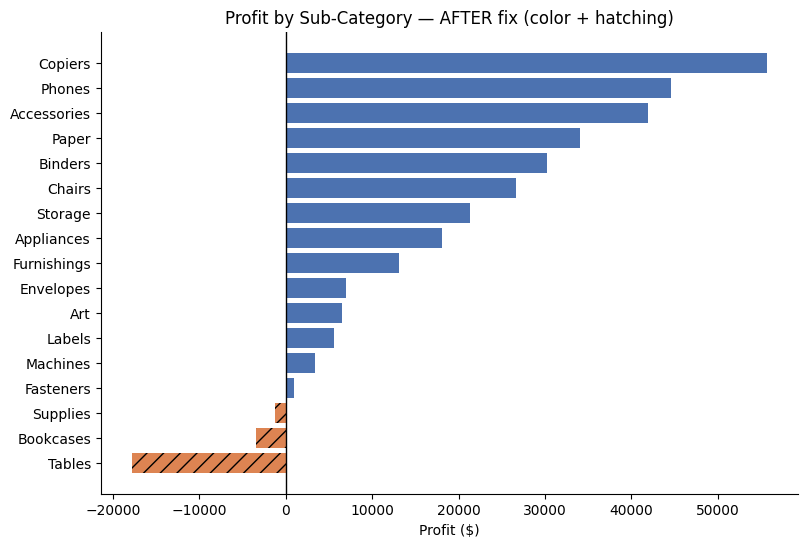

In [20]:
# --- Version 2: the FIXED version — color AND pattern (hatching) together ---
colors_fixed = ['#DD8452' if v < 0 else '#4C72B0' for v in profit_by_subcat.values]
hatches = ['//' if v < 0 else '' for v in profit_by_subcat.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_fixed)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Profit by Sub-Category — AFTER fix (color + hatching)')
ax.set_xlabel('Profit ($)')
plt.show()

**The fix:** Losses now use a different color (orange, not red) **and** diagonal hatching, while gains stay plain blue. Even if someone cannot tell orange from blue by color, the hatching pattern still tells them which bars are losses — the distinction survives the colorblindness simulation.

**Alt text for this chart:** "Horizontal bar chart of profit by product sub-category. Bars with diagonal hatching represent a loss (profit below zero); solid bars represent a gain. Tables and Bookcases show the largest losses; Copiers and Phones show the largest gains."</br>

## Task 5 — Misleading visualizations
Here we deliberately build misleading charts to show how each trick distorts the data, using region sales and monthly profit/sales.

### 5a. Truncated y-axis on region sales

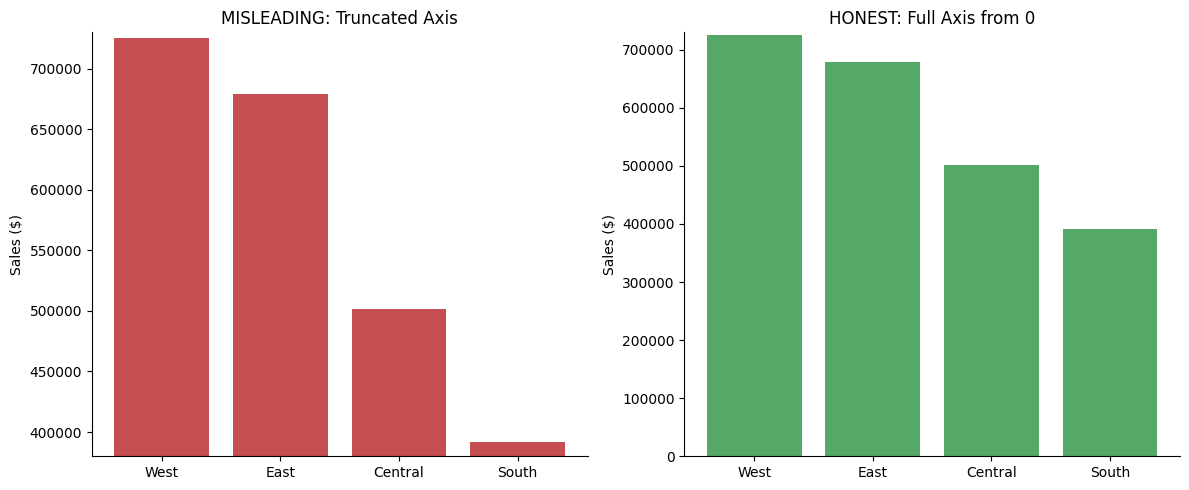

In [21]:
region_sales_sorted = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Misleading: y-axis starts near the smallest value, not at 0
axes[0].bar(region_sales_sorted.index, region_sales_sorted.values, color='#C44E52')
axes[0].set_ylim(380000, 730000)
axes[0].set_title('MISLEADING: Truncated Axis')
axes[0].set_ylabel('Sales ($)')

# Honest: y-axis starts at 0, showing the true scale
axes[1].bar(region_sales_sorted.index, region_sales_sorted.values, color='#55A868')
axes[1].set_ylim(0, 730000)
axes[1].set_title('HONEST: Full Axis from 0')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()

**Distortion mechanism:** Starting the y-axis near the minimum value (instead of 0) exaggerates small differences between regions, making the West region look many times bigger than the South, when the real difference is much smaller.

### 5b. Dual-axis chart implying a fake correlation

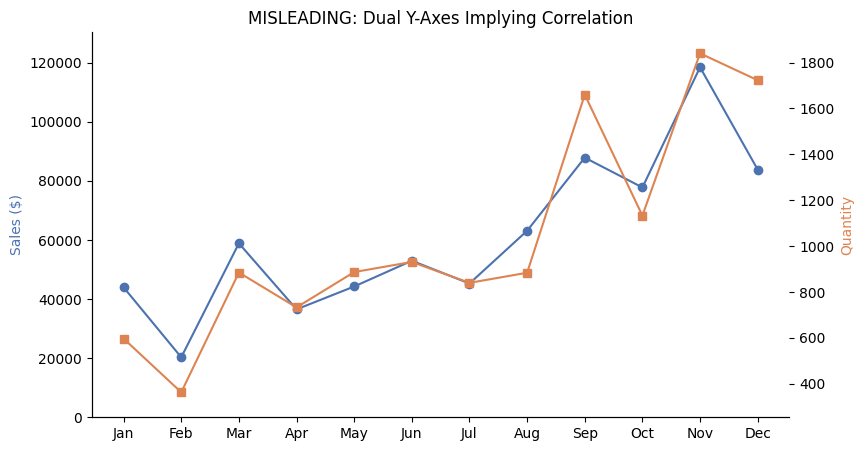

In [22]:
# Two measures that aren't really related in a meaningful way at this scale:
# monthly sales and monthly order quantity, forced onto two different axes
monthly_qty_2017 = sales_2017.groupby(sales_2017['Order Date'].dt.month)['Quantity'].sum()
monthly_qty_2017.index = month_names

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(monthly_sales.index, monthly_sales.values, color='#4C72B0', marker='o', label='Sales')
ax1.set_ylabel('Sales ($)', color='#4C72B0')
ax1.set_ylim(0, monthly_sales.max() * 1.1)

ax2 = ax1.twinx()
# Squeezing quantity's axis to visually hug the sales line
ax2.plot(monthly_qty_2017.index, monthly_qty_2017.values, color='#DD8452', marker='s', label='Quantity')
ax2.set_ylabel('Quantity', color='#DD8452')
ax2.set_ylim(monthly_qty_2017.min() * 0.7, monthly_qty_2017.max() * 1.05)

plt.title('MISLEADING: Dual Y-Axes Implying Correlation')
plt.show()

**Distortion mechanism:** Each line has its own independently scaled axis, so by stretching or squeezing one axis, the two lines can be made to visually line up — making it look like sales and quantity move together in lockstep, even though the real numbers behind them may not be as tightly related.

### 5c. Cherry-picked date window hiding the surrounding trend

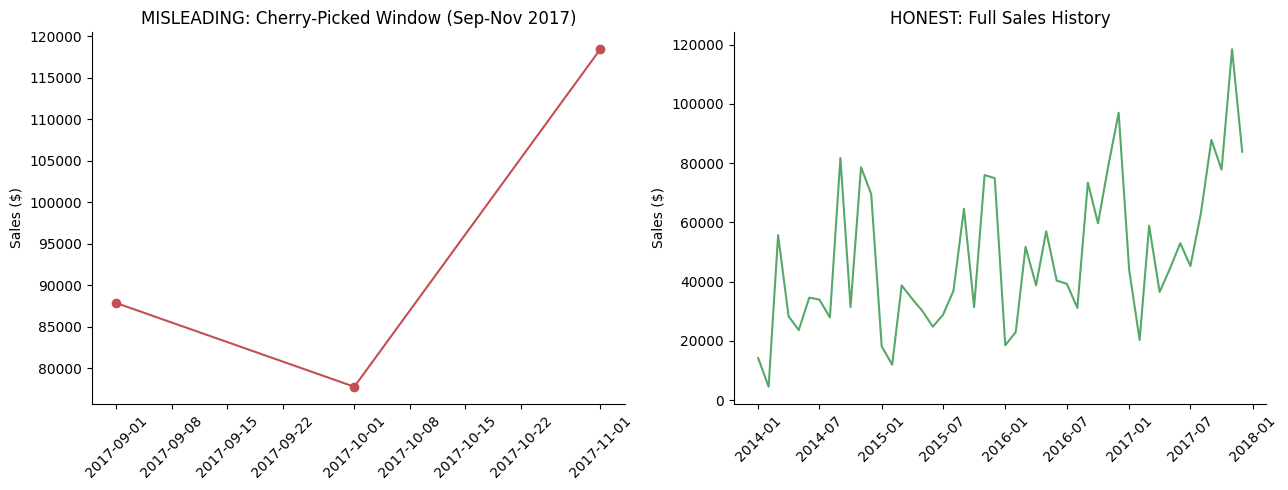

In [23]:
all_monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
all_monthly_sales.index = all_monthly_sales.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Misleading: only show a short window that supports a "sales are rising" story
window = all_monthly_sales['2017-09':'2017-11']
axes[0].plot(window.index, window.values, marker='o', color='#C44E52')
axes[0].set_title('MISLEADING: Cherry-Picked Window (Sep-Nov 2017)')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Honest: show the full history
axes[1].plot(all_monthly_sales.index, all_monthly_sales.values, color='#55A868')
axes[1].set_title('HONEST: Full Sales History')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Distortion mechanism:** Showing only Sep-Nov 2017 makes sales look like they are on a steady, uninterrupted climb. The full history reveals this is just one small upward stretch inside a much bumpier, seasonal pattern.

### 5d. Inverted y-axis on monthly profit

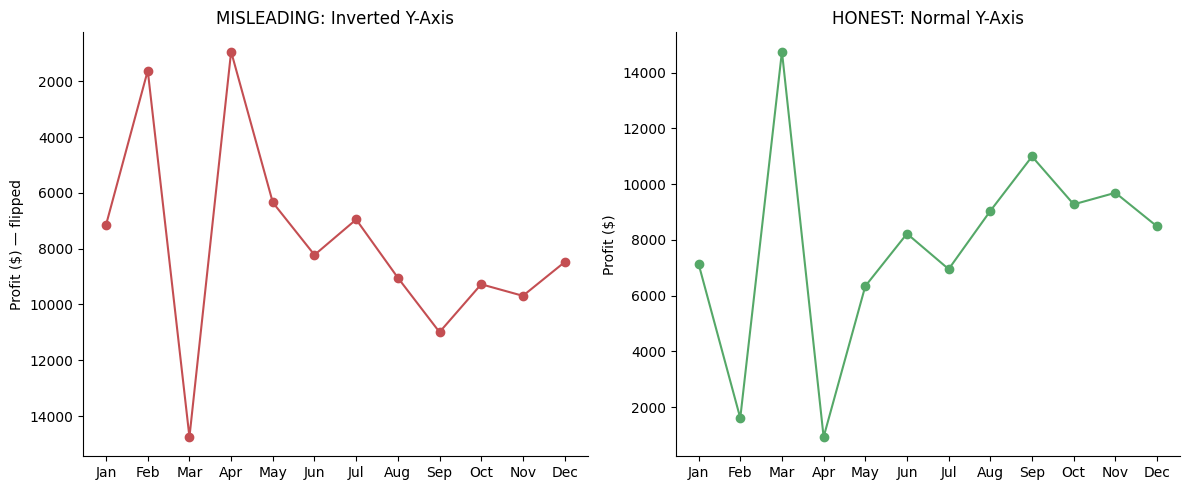

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Misleading: y-axis is flipped upside down
axes[0].plot(monthly_profit_2017.index, monthly_profit_2017.values, marker='o', color='#C44E52')
axes[0].invert_yaxis()
axes[0].set_title('MISLEADING: Inverted Y-Axis')
axes[0].set_ylabel('Profit ($) — flipped')

# Honest: normal y-axis
axes[1].plot(monthly_profit_2017.index, monthly_profit_2017.values, marker='o', color='#55A868')
axes[1].set_title('HONEST: Normal Y-Axis')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

**Distortion mechanism:** Flipping the y-axis makes rising profit look like it's falling and falling profit look like it's rising — a viewer reading the shape of the line the normal way (up = good) will draw exactly the wrong conclusion.

### 5e. Bubble chart where radius (not area) scales with value

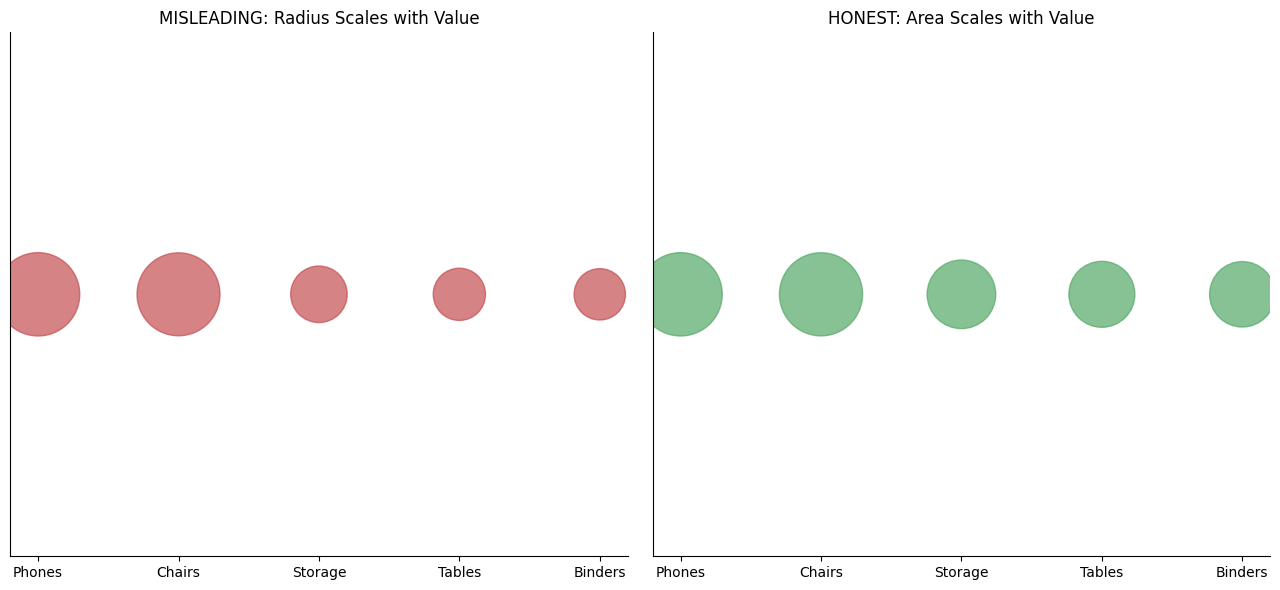

In [25]:
top5_subcat_vals = top5_subcat.values
labels = top5_subcat.index
x_positions = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Misleading: bubble RADIUS is directly proportional to sales
# so a 2x bigger value gets 4x the visual area, exaggerating differences
max_val = top5_subcat_vals.max()
radius_scale = 60
sizes_radius = [(v / max_val) * radius_scale for v in top5_subcat_vals]
axes[0].scatter(x_positions, [1]*len(labels), s=[r**2 for r in sizes_radius], color='#C44E52', alpha=0.7)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(labels)
axes[0].set_yticks([])
axes[0].set_title('MISLEADING: Radius Scales with Value')

# Honest: bubble AREA is directly proportional to sales
sizes_area = [(v / max_val) * (radius_scale**2) for v in top5_subcat_vals]
axes[1].scatter(x_positions, [1]*len(labels), s=sizes_area, color='#55A868', alpha=0.7)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(labels)
axes[1].set_yticks([])
axes[1].set_title('HONEST: Area Scales with Value')

plt.tight_layout()
plt.show()

**Distortion mechanism:** When bubble *radius* scales directly with the value, a value that is 2x as large ends up with 4x the visual area (since area grows with the square of the radius) — so the biggest sub-category looks far more dominant than it actually is. Scaling *area* directly instead keeps the visual impression proportional to the real numbers.

## Task 6 — A real analytical question: Is discounting hurting profit?
We answer this with one honest chart and one deliberately misleading version, then justify our choices.

In [26]:
# Group orders into discount bands, and look at average profit per band
df['Discount Band'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 1.0],
                              labels=['0%', '1-20%', '21-40%', '41%+'])
discount_profit = df.groupby('Discount Band', observed=True)['Profit'].mean()
discount_profit

Discount Band
0%         66.900292
1-20%      26.501571
21-40%    -77.864055
41%+     -106.708028
Name: Profit, dtype: float64

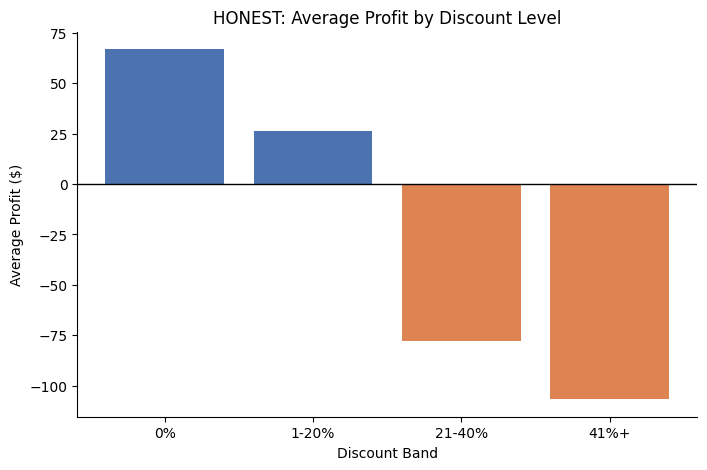

In [27]:
# HONEST chart: bar chart starting at 0, showing the true scale, with a clear label
colors_honest = ['#4C72B0' if v >= 0 else '#DD8452' for v in discount_profit.values]

plt.figure(figsize=(8, 5))
plt.bar(discount_profit.index.astype(str), discount_profit.values, color=colors_honest)
plt.axhline(0, color='black', linewidth=1)
plt.title('HONEST: Average Profit by Discount Level')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit ($)')
plt.show()

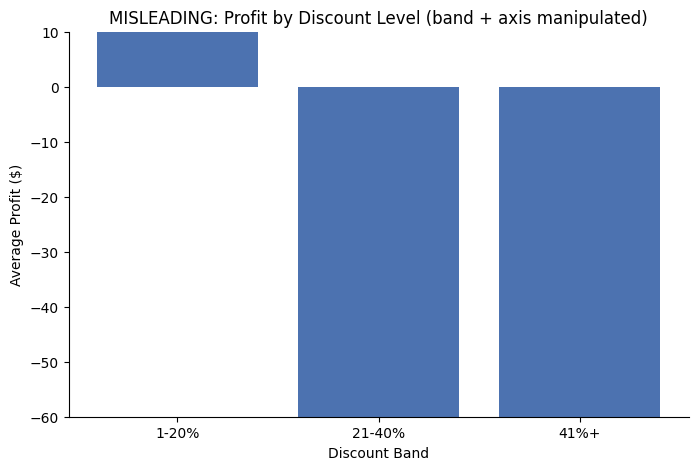

In [28]:
# MISLEADING chart: truncated axis + cherry-picked bands (skips the 0% band, which is
# the most profitable and would ruin the "discounting isn't that bad" story)
misleading_data = discount_profit.drop('0%')

plt.figure(figsize=(8, 5))
plt.bar(misleading_data.index.astype(str), misleading_data.values, color='#4C72B0')
plt.ylim(-60, 10)  # truncated axis, exaggerates the small remaining differences
plt.title('MISLEADING: Profit by Discount Level (band + axis manipulated)')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit ($)')
plt.show()

**Written justification:**

- **Chart type:** A bar chart is the right choice here because we are comparing an average value (profit) across a small number of discrete groups (discount bands) — exactly the "compare magnitudes across categories" case from the effectiveness table.
- **Color choice:** The honest chart uses a diverging idea — blue for average profit that is still positive, orange for average profit that has turned negative — because profit crosses zero and the sign (gain vs. loss) is the most important thing to see at a glance.
- **Accessibility check:** Blue and orange were used instead of red/green so the chart does not rely on a colorblind-unsafe pair, and the zero line is also marked with a solid black reference line, so the gain/loss split does not depend on color alone.
- **What the honest chart shows:** Average profit is positive with no discount, and drops further into a loss the higher the discount band goes — so yes, heavier discounting is associated with lower (and eventually negative) profit.
- **How the misleading version distorts this:** It drops the 0% discount band entirely (the most profitable one, which is inconvenient for a "discounts aren't so bad" narrative) and truncates the y-axis to a narrow range, which exaggerates the differences between the remaining bands and hides how much worse discounting is compared to no discount at all.